# Exploratory Data Analysis
Dissolved Oxygen Prediction System — Combined Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 110

RAW_PATH = r"C:\IOMP\DissolvedOxygen_Predictor\data\raw\Combined_dataset.csv"
df = pd.read_csv(RAW_PATH, low_memory=False)
print(f'Shape: {df.shape}')
df.head()

Shape: (2827977, 14)


,Country,Area,Waterbody Type,Date,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,CCME_WQI
0,Canada,SE649035-145565,River,12-01-1974,0.059248,1.30,8.1500,0.011917,8.07500,9.885,0.343917,11.73155,100.0,Excellent
1,Canada,SE649035-145565,River,12-01-1975,0.039821,1.38,7.8000,0.009417,7.73333,10.150,0.449083,11.82009,100.0,Excellent
2,Canada,SE649035-145565,River,12-01-1976,0.031341,2.23,7.8000,0.011000,7.46667,10.235,0.220750,14.87472,100.0,Excellent
3,Canada,SE649035-145565,River,12-01-1977,0.020501,1.61,8.1500,0.012333,7.78333,11.116,0.572250,15.89293,100.0,Excellent
4,Canada,SE649035-145565,River,12-01-1978,0.020023,1.64,4.3708,0.006182,7.10000,7.068,0.371091,15.22888,100.0,Excellent


## 1. Dataset overview

In [3]:
print('=== Column types ===')
print(df.dtypes)
print('\n=== Basic stats ===')
df.describe().round(3)

=== Column types ===
Country                                 str
Area                                    str
Waterbody Type                          str
Date                                    str
Ammonia (mg/l)                      float64
Biochemical Oxygen Demand (mg/l)    float64
Dissolved Oxygen (mg/l)             float64
Orthophosphate (mg/l)               float64
pH (ph units)                       float64
Temperature (cel)                   float64
Nitrogen (mg/l)                     float64
Nitrate (mg/l)                      float64
CCME_Values                         float64
CCME_WQI                                str
dtype: object

=== Basic stats ===


,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values
count,2827977.000,2827977.000,2827977.000,2827977.000,2827977.000,2827977.000,2827977.00,2827977.000,2827977.000
mean,1.171,4.887,10.008,0.710,7.736,11.839,5.21,4.767,85.047
std,5.669,16.414,1.851,2.089,0.495,5.010,6.20,6.074,17.647
min,-0.005,-2.000,0.000,-0.004,-1.000,-5.260,0.00,0.000,31.304
25%,0.030,1.600,9.860,0.040,7.550,8.990,0.78,1.173,77.153
50%,0.055,2.700,10.200,0.107,7.780,11.460,4.00,4.500,90.596
75%,0.317,2.830,11.000,0.227,8.000,14.200,6.32,4.940,100.000
max,200.000,255.000,20.000,100.000,30.000,98.000,46.00,155.000,100.000


## 2. Missing values

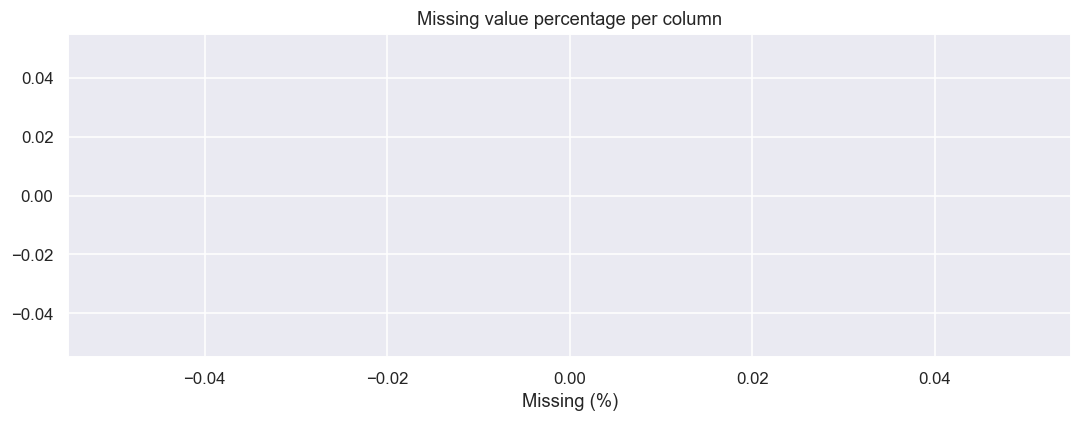

Empty DataFrame
Columns: [missing, pct]
Index: []


In [4]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'missing': missing, 'pct': pct}).query('missing > 0').sort_values('pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(miss_df.index, miss_df['pct'], color='#e24b4a')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing value percentage per column')
plt.tight_layout()
plt.show()
print(miss_df)

## 3. Country & waterbody distribution

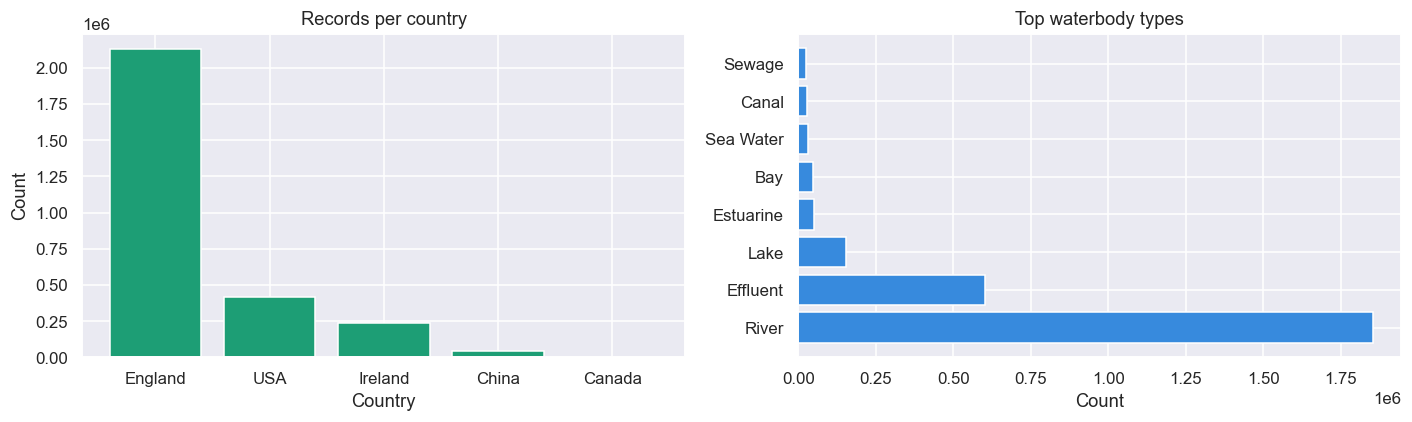

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

country_counts = df['Country'].value_counts()
axes[0].bar(country_counts.index, country_counts.values, color='#1d9e75')
axes[0].set_title('Records per country')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Count')

wb_counts = df['Waterbody Type'].value_counts().head(8)
axes[1].barh(wb_counts.index, wb_counts.values, color='#378add')
axes[1].set_title('Top waterbody types')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 4. Feature distributions

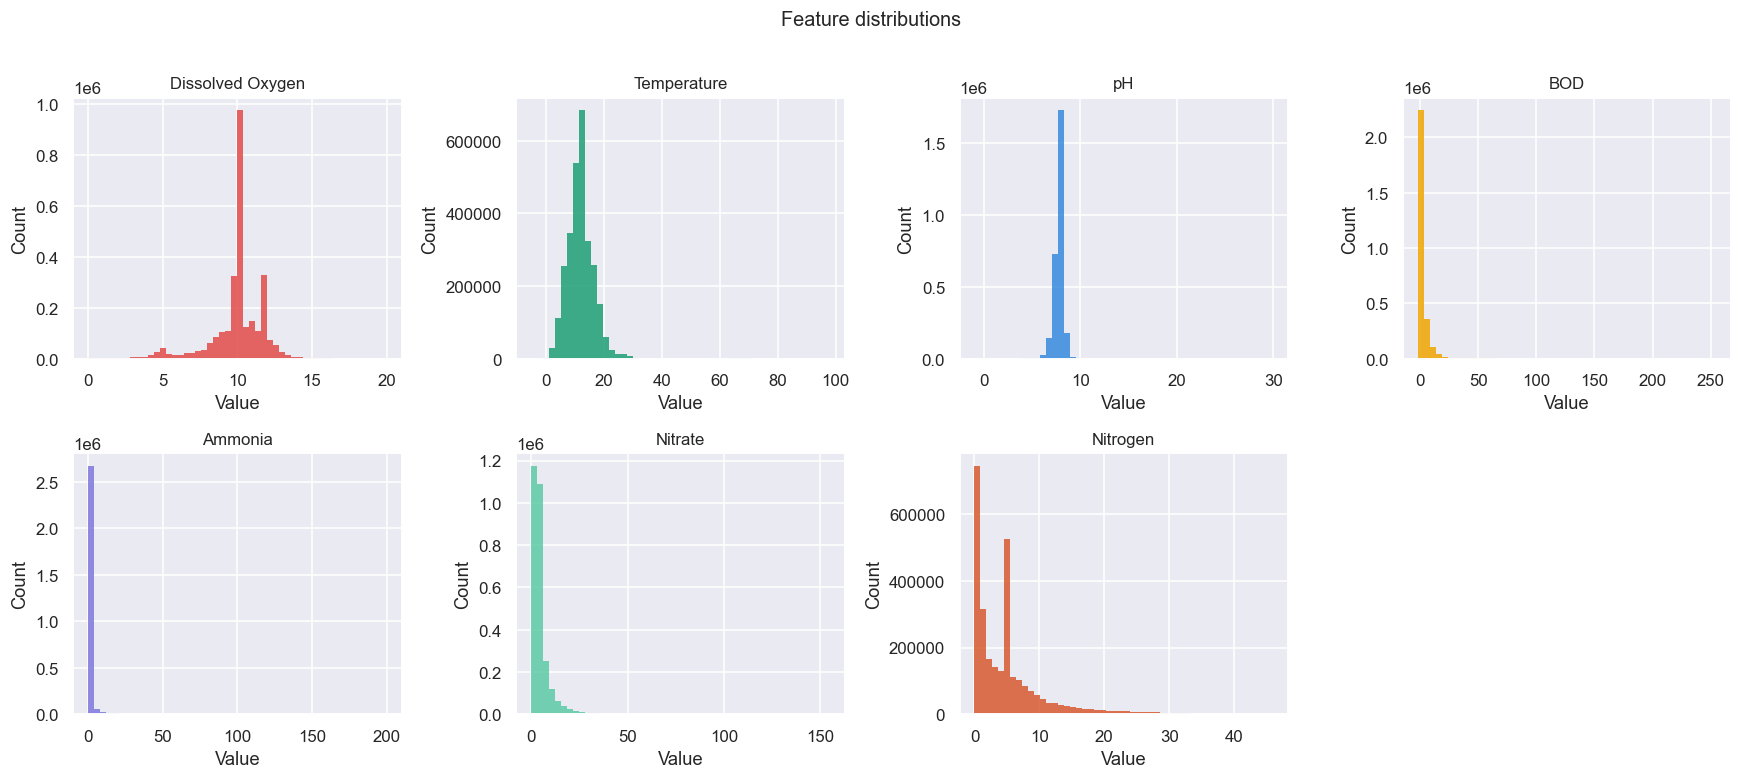

In [6]:
num_cols = [
    'Dissolved Oxygen (mg/l)', 'Temperature (cel)', 'pH (ph units)',
    'Biochemical Oxygen Demand (mg/l)', 'Ammonia (mg/l)',
    'Nitrate (mg/l)', 'Nitrogen (mg/l)'
]
labels = ['Dissolved Oxygen', 'Temperature', 'pH', 'BOD', 'Ammonia', 'Nitrate', 'Nitrogen']
colors = ['#e24b4a','#1d9e75','#378add','#f0a500','#7f77dd','#5dcaa5','#d85a30']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, (col, label, color) in enumerate(zip(num_cols, labels, colors)):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color=color, alpha=0.85, edgecolor='none')
    axes[i].set_title(label, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Feature distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. DO levels by country

C:\Users\728sa\AppData\Local\Temp\ipykernel_24588\2946646677.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(do_by_country, labels=df['Country'].unique(), patch_artist=True,


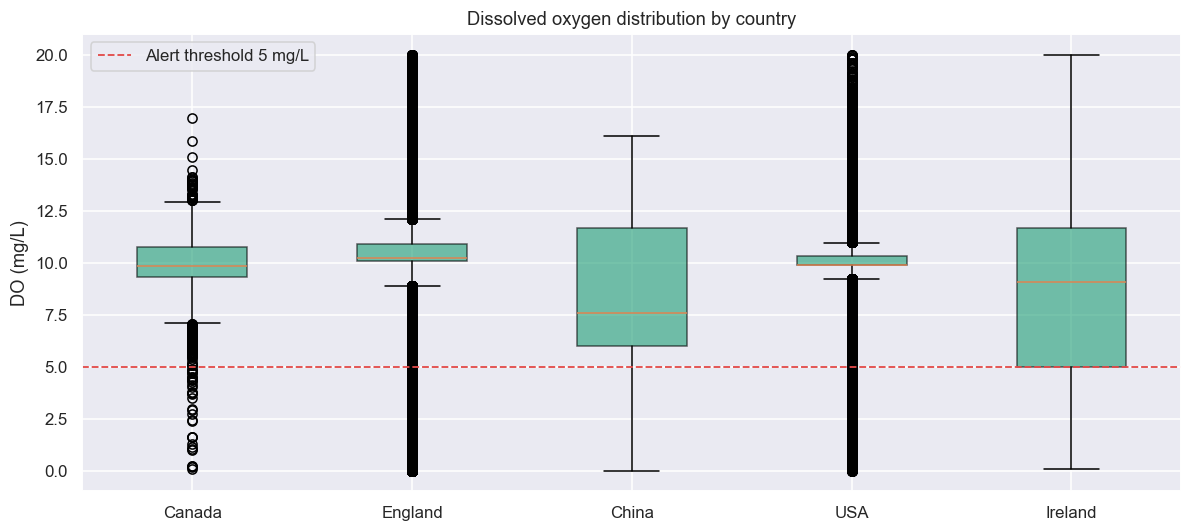

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
do_by_country = [df[df['Country'] == c]['Dissolved Oxygen (mg/l)'].dropna().values
                 for c in df['Country'].unique()]
ax.boxplot(do_by_country, labels=df['Country'].unique(), patch_artist=True,
           boxprops=dict(facecolor='#1d9e75', alpha=0.6))
ax.axhline(5, color='#e24b4a', linestyle='--', linewidth=1.2, label='Alert threshold 5 mg/L')
ax.set_title('Dissolved oxygen distribution by country')
ax.set_ylabel('DO (mg/L)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Correlation heatmap

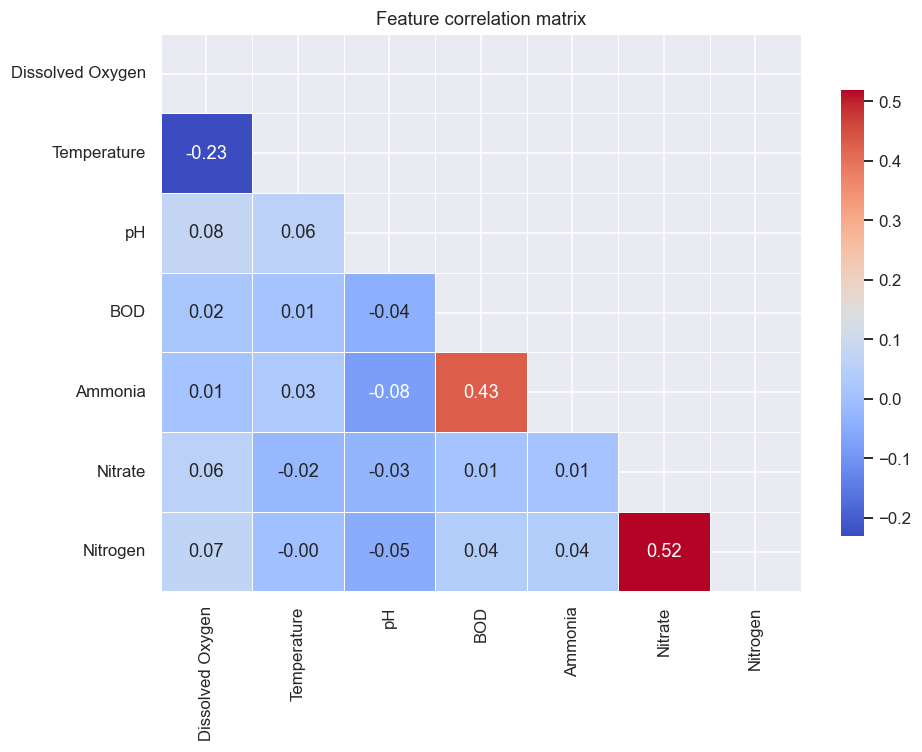

In [8]:
corr = df[num_cols].rename(columns=dict(zip(num_cols, labels))).corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

## 7. DO vs each feature (scatter)

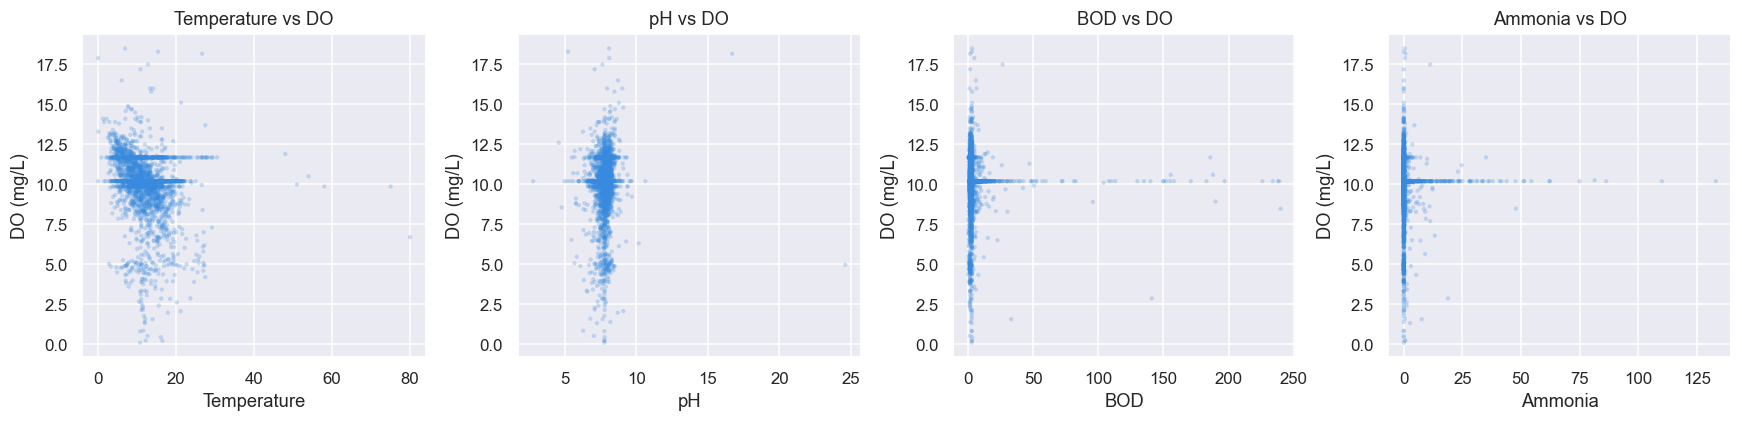

In [9]:
feature_cols = ['Temperature (cel)','pH (ph units)',
                'Biochemical Oxygen Demand (mg/l)','Ammonia (mg/l)']
feat_labels  = ['Temperature','pH','BOD','Ammonia']

sample = df.dropna(subset=['Dissolved Oxygen (mg/l)']).sample(3000, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, label in zip(axes, feature_cols, feat_labels):
    ax.scatter(sample[col], sample['Dissolved Oxygen (mg/l)'],
               alpha=0.25, s=8, color='#378add', edgecolors='none')
    ax.set_xlabel(label)
    ax.set_ylabel('DO (mg/L)')
    ax.set_title(f'{label} vs DO')

plt.tight_layout()
plt.show()

## 8. DO alert analysis — how many readings are below 5 mg/L?

Readings below 5 mg/L: 105,665 / 2,827,977  (3.7%)


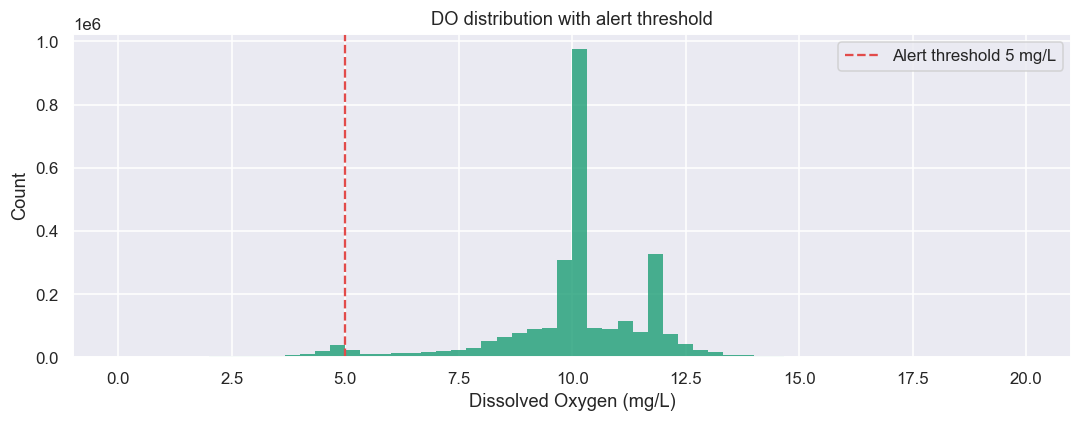

In [10]:
do = df['Dissolved Oxygen (mg/l)'].dropna()
alert_pct = (do < 5).sum() / len(do) * 100
print(f'Readings below 5 mg/L: {(do < 5).sum():,} / {len(do):,}  ({alert_pct:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(do, bins=60, color='#1d9e75', alpha=0.8, edgecolor='none')
ax.axvline(5, color='#e24b4a', linestyle='--', linewidth=1.5, label='Alert threshold 5 mg/L')
ax.set_xlabel('Dissolved Oxygen (mg/L)')
ax.set_ylabel('Count')
ax.set_title('DO distribution with alert threshold')
ax.legend()
plt.tight_layout()
plt.show()